# 11. 卷积神经网络（高级篇）


之前的全连接神经网络(多层感知机)和CNN都是串行结构，前一层的输入是后一层的输出

Inception Moudel

1、卷积核超参数选择困难，自动找到卷积的最佳组合。

2、1x1卷积核，不同通道 的信息融合。使用1x1卷积核虽然参数量增加了，但是能够显著的降低计算量(operations)

3、Inception Moudel由4个分支组成，要分清哪些是在Init里定义，哪些是在forward里调用。4个分支在dim=1(通道channels) (dim0123分别是batch，channel，w，h)上进行concatenate。24+16+24+24 = 88

4、GoogleNet的Inception(Pytorch实现)

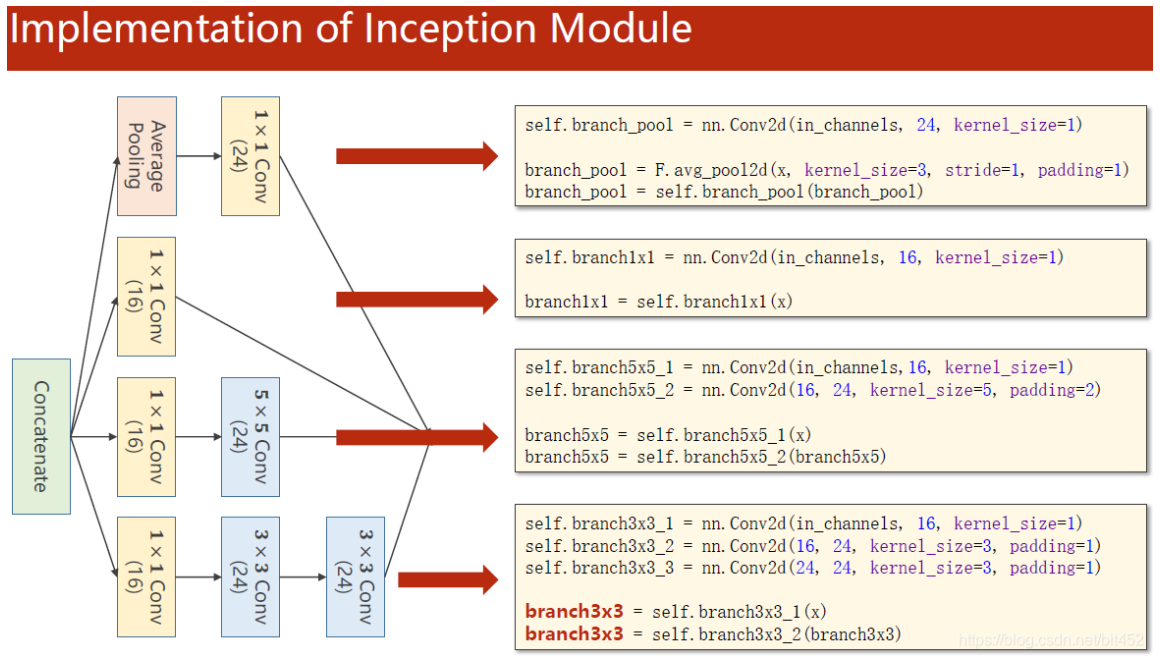

代码说明：

1、先使用类 对Inception Moudel进行封装

2、先是1个卷积层(conv,maxpooling,relu)，然后inceptionA模块(输出的channels是24+16+24+24=88)，接下来又是一个卷积层(conv,mp,relu),然后inceptionA模块，最后一个全连接层(fc)。

3、1408这个数据可以通过x = x.view(in_size, -1)后调用x.shape得到。

In [1]:
import torch
import torch.nn as nn
from torchvision import transforms
from torchvision import datasets
from torch.utils.data import DataLoader
import torch.nn.functional as F
import torch.optim as optim
 
# prepare dataset
 
batch_size = 64
transform = transforms.Compose([transforms.ToTensor(), transforms.Normalize((0.1307,), (0.3081,))]) # 归一化,均值和方差
 
train_dataset = datasets.MNIST(root='../dataset/mnist/', train=True, download=True, transform=transform)
train_loader = DataLoader(train_dataset, shuffle=True, batch_size=batch_size)
test_dataset = datasets.MNIST(root='../dataset/mnist/', train=False, download=True, transform=transform)
test_loader = DataLoader(test_dataset, shuffle=False, batch_size=batch_size)
 
# design model using class
class InceptionA(nn.Module):
    def __init__(self, in_channels):
        super(InceptionA, self).__init__()
        self.branch1x1 = nn.Conv2d(in_channels, 16, kernel_size=1)
 
        self.branch5x5_1 = nn.Conv2d(in_channels, 16, kernel_size=1)
        self.branch5x5_2 = nn.Conv2d(16, 24, kernel_size=5, padding=2)
 
        self.branch3x3_1 = nn.Conv2d(in_channels, 16, kernel_size=1)
        self.branch3x3_2 = nn.Conv2d(16, 24, kernel_size=3, padding=1)
        self.branch3x3_3 = nn.Conv2d(24, 24, kernel_size=3, padding=1)
 
        self.branch_pool = nn.Conv2d(in_channels, 24, kernel_size=1)
 
    def forward(self, x):
        branch1x1 = self.branch1x1(x)
 
        branch5x5 = self.branch5x5_1(x)
        branch5x5 = self.branch5x5_2(branch5x5)
 
        branch3x3 = self.branch3x3_1(x)
        branch3x3 = self.branch3x3_2(branch3x3)
        branch3x3 = self.branch3x3_3(branch3x3)
 
        branch_pool = F.avg_pool2d(x, kernel_size=3, stride=1, padding=1)
        branch_pool = self.branch_pool(branch_pool)
 
        outputs = [branch1x1, branch5x5, branch3x3, branch_pool]
        return torch.cat(outputs, dim=1) # b,c,w,h  c对应的是dim=1
 
class Net(nn.Module):
    def __init__(self):
        super(Net, self).__init__()
        self.conv1 = nn.Conv2d(1, 10, kernel_size=5)
        self.conv2 = nn.Conv2d(88, 20, kernel_size=5) # 88 = 24x3 + 16
 
        self.incep1 = InceptionA(in_channels=10) # 与conv1 中的10对应
        self.incep2 = InceptionA(in_channels=20) # 与conv2 中的20对应
 
        self.mp = nn.MaxPool2d(2)
        self.fc = nn.Linear(1408, 10) 
 
 
    def forward(self, x):
        in_size = x.size(0)
        x = F.relu(self.mp(self.conv1(x)))
        x = self.incep1(x)
        x = F.relu(self.mp(self.conv2(x)))
        x = self.incep2(x)
        x = x.view(in_size, -1)
        x = self.fc(x)
 
        return x
 
model = Net()
 
# construct loss and optimizer
criterion = torch.nn.CrossEntropyLoss()
optimizer = optim.SGD(model.parameters(), lr=0.01, momentum=0.5)
 
# training cycle forward, backward, update
 
 
def train(epoch):
    running_loss = 0.0
    for batch_idx, data in enumerate(train_loader, 0):
        inputs, target = data
        optimizer.zero_grad()
 
        outputs = model(inputs)
        loss = criterion(outputs, target)
        loss.backward()
        optimizer.step()
 
        running_loss += loss.item()
        if batch_idx % 300 == 299:
            print('[%d, %5d] loss: %.3f' % (epoch+1, batch_idx+1, running_loss/300))
            running_loss = 0.0
 
 
def test():
    correct = 0
    total = 0
    with torch.no_grad():
        for data in test_loader:
            images, labels = data
            outputs = model(images)
            _, predicted = torch.max(outputs.data, dim=1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    print('accuracy on test set: %d %% ' % (100*correct/total))
 
 
if __name__ == '__main__':
    for epoch in range(10):
        train(epoch)
        test()

[1,   300] loss: 1.042
[1,   600] loss: 0.243
[1,   900] loss: 0.154
accuracy on test set: 96 % 
[2,   300] loss: 0.112
[2,   600] loss: 0.109
[2,   900] loss: 0.094
accuracy on test set: 97 % 
[3,   300] loss: 0.085
[3,   600] loss: 0.076
[3,   900] loss: 0.073
accuracy on test set: 98 % 
[4,   300] loss: 0.071
[4,   600] loss: 0.064
[4,   900] loss: 0.060
accuracy on test set: 98 % 
[5,   300] loss: 0.058
[5,   600] loss: 0.053
[5,   900] loss: 0.057
accuracy on test set: 98 % 
[6,   300] loss: 0.048
[6,   600] loss: 0.051
[6,   900] loss: 0.049
accuracy on test set: 98 % 
[7,   300] loss: 0.045
[7,   600] loss: 0.044
[7,   900] loss: 0.050
accuracy on test set: 98 % 
[8,   300] loss: 0.042
[8,   600] loss: 0.043
[8,   900] loss: 0.041
accuracy on test set: 98 % 
[9,   300] loss: 0.034
[9,   600] loss: 0.043
[9,   900] loss: 0.040
accuracy on test set: 98 % 
[10,   300] loss: 0.032
[10,   600] loss: 0.037
[10,   900] loss: 0.038
accuracy on test set: 98 % 


Residual Net：解决梯度消失，因为layer变多会使得最开始的层的梯度变小因为是链式法则，所以会->0，不好更新

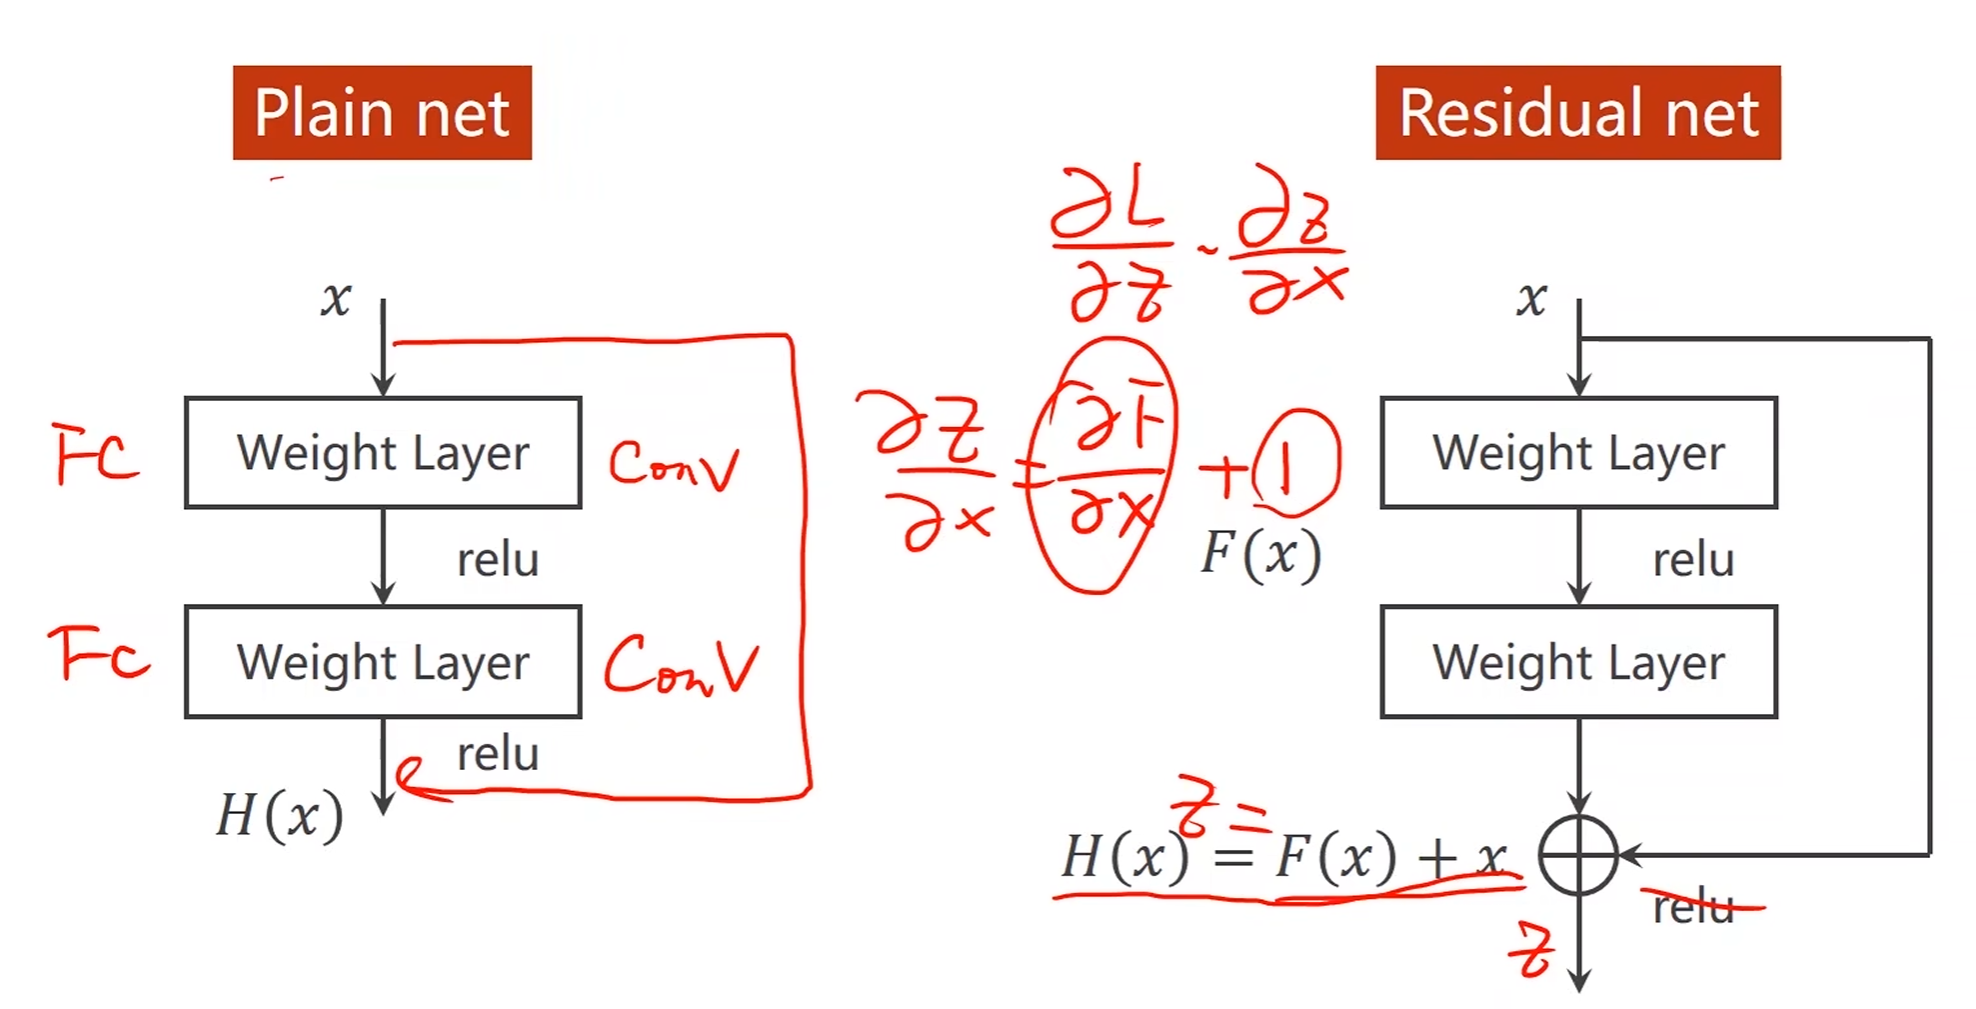

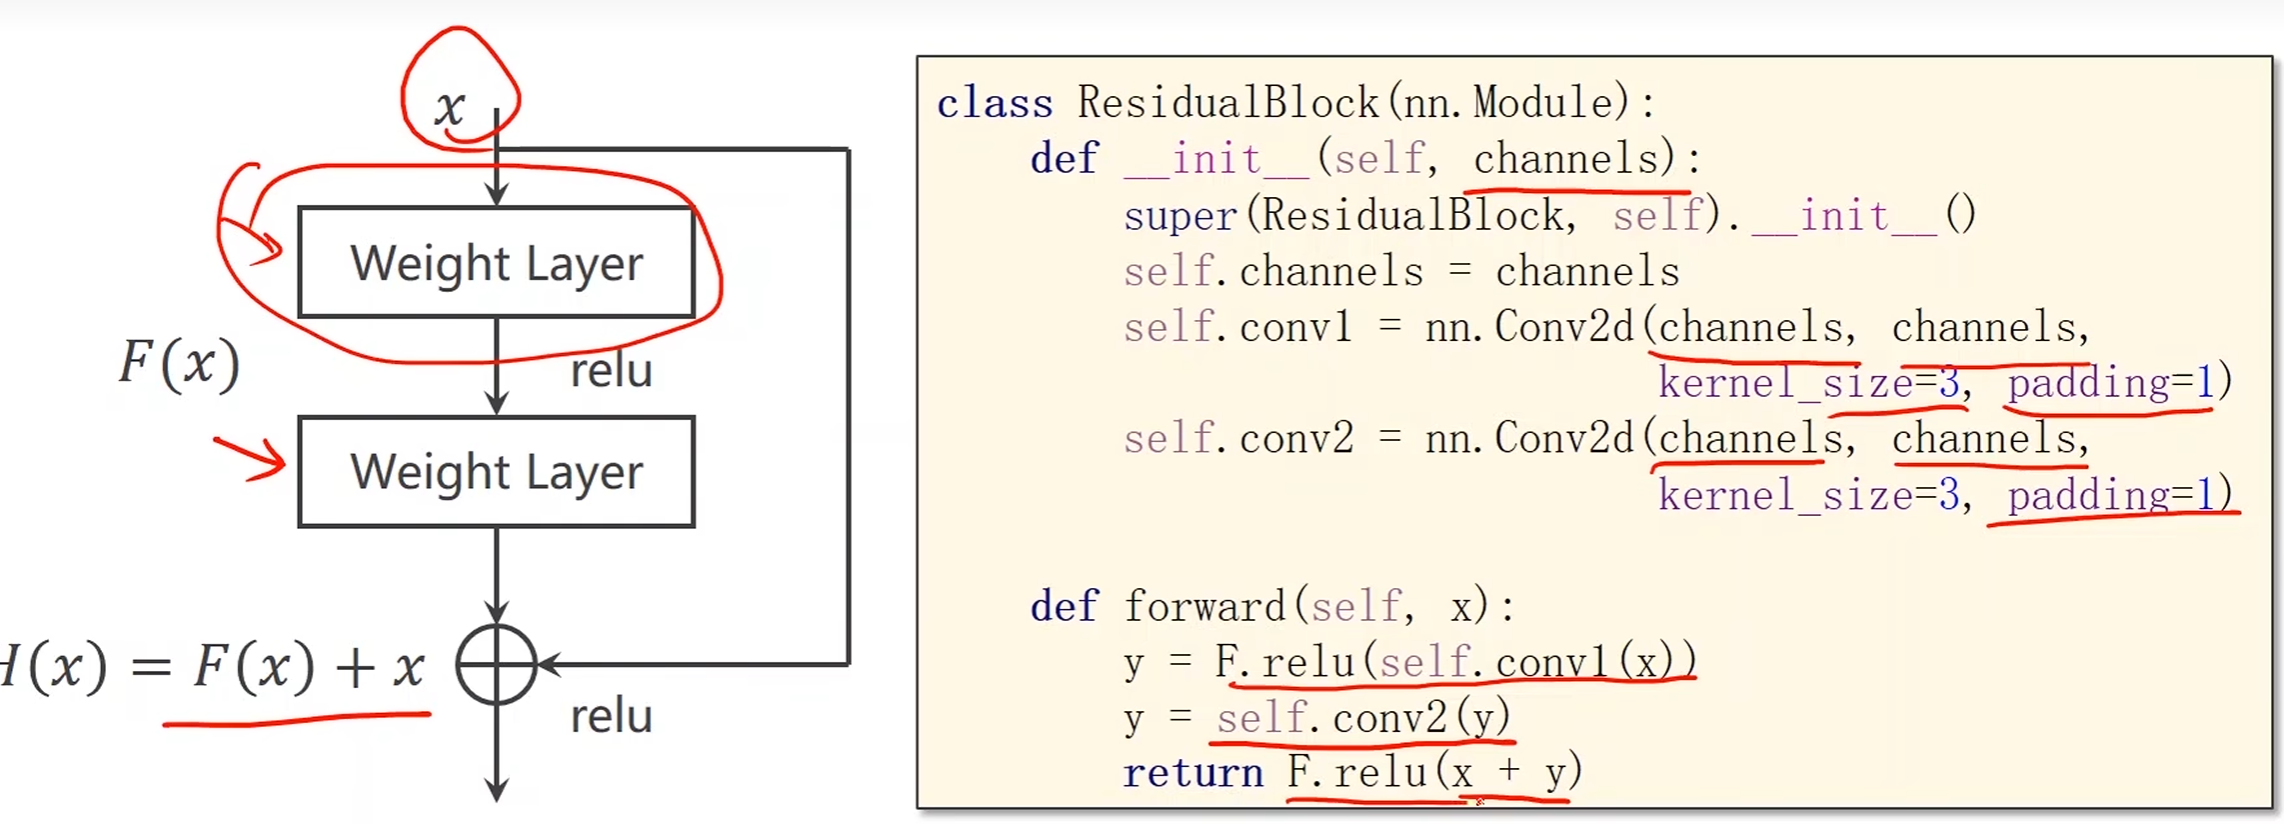

In [2]:
import torch
import torch.nn as nn
from torchvision import transforms
from torchvision import datasets
from torch.utils.data import DataLoader
import torch.nn.functional as F
import torch.optim as optim
 
# prepare dataset
 
batch_size = 64
transform = transforms.Compose([transforms.ToTensor(), transforms.Normalize((0.1307,), (0.3081,))]) # 归一化,均值和方差
 
train_dataset = datasets.MNIST(root='../dataset/mnist/', train=True, download=True, transform=transform)
train_loader = DataLoader(train_dataset, shuffle=True, batch_size=batch_size)
test_dataset = datasets.MNIST(root='../dataset/mnist/', train=False, download=True, transform=transform)
test_loader = DataLoader(test_dataset, shuffle=False, batch_size=batch_size)
 
# design model using class
class ResidualBlock(nn.Module):
    def __init__(self, channels):
        super(ResidualBlock, self).__init__()
        self.channels = channels
        self.conv1 = nn.Conv2d(channels, channels, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(channels, channels, kernel_size=3, padding=1)
 
    def forward(self, x):
        y = F.relu(self.conv1(x))
        y = self.conv2(y)
        return F.relu(x + y)
 
class Net(nn.Module):
    def __init__(self):
        super(Net, self).__init__()
        self.conv1 = nn.Conv2d(1, 16, kernel_size=5)
        self.conv2 = nn.Conv2d(16, 32, kernel_size=5) # 88 = 24x3 + 16
 
        self.rblock1 = ResidualBlock(16)
        self.rblock2 = ResidualBlock(32)
 
        self.mp = nn.MaxPool2d(2)
        self.fc = nn.Linear(512, 10) # 暂时不知道1408咋能自动出来的
 
 
    def forward(self, x):
        in_size = x.size(0)
 
        x = self.mp(F.relu(self.conv1(x)))
        x = self.rblock1(x)
        x = self.mp(F.relu(self.conv2(x)))
        x = self.rblock2(x)
 
        x = x.view(in_size, -1)
        x = self.fc(x)
        return x
 
model = Net()
 
# construct loss and optimizer
criterion = torch.nn.CrossEntropyLoss()
optimizer = optim.SGD(model.parameters(), lr=0.01, momentum=0.5)
 
# training cycle forward, backward, update
 
 
def train(epoch):
    running_loss = 0.0
    for batch_idx, data in enumerate(train_loader, 0):
        inputs, target = data
        optimizer.zero_grad()
 
        outputs = model(inputs)
        loss = criterion(outputs, target)
        loss.backward()
        optimizer.step()
 
        running_loss += loss.item()
        if batch_idx % 300 == 299:
            print('[%d, %5d] loss: %.3f' % (epoch+1, batch_idx+1, running_loss/300))
            running_loss = 0.0
 
 
def test():
    correct = 0
    total = 0
    with torch.no_grad():
        for data in test_loader:
            images, labels = data
            outputs = model(images)
            _, predicted = torch.max(outputs.data, dim=1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    print('accuracy on test set: %d %% ' % (100*correct/total))
 
 
if __name__ == '__main__':
    for epoch in range(10):
        train(epoch)
        test()

[1,   300] loss: 0.536
[1,   600] loss: 0.163
[1,   900] loss: 0.119
accuracy on test set: 96 % 
[2,   300] loss: 0.092
[2,   600] loss: 0.082
[2,   900] loss: 0.078
accuracy on test set: 98 % 
[3,   300] loss: 0.069
[3,   600] loss: 0.057
[3,   900] loss: 0.059
accuracy on test set: 98 % 
[4,   300] loss: 0.048
[4,   600] loss: 0.052
[4,   900] loss: 0.048
accuracy on test set: 98 % 
[5,   300] loss: 0.042
[5,   600] loss: 0.041
[5,   900] loss: 0.042
accuracy on test set: 98 % 
[6,   300] loss: 0.036
[6,   600] loss: 0.035
[6,   900] loss: 0.036
accuracy on test set: 98 % 
[7,   300] loss: 0.027
[7,   600] loss: 0.034
[7,   900] loss: 0.032
accuracy on test set: 98 % 
[8,   300] loss: 0.028
[8,   600] loss: 0.028
[8,   900] loss: 0.029
accuracy on test set: 98 % 
[9,   300] loss: 0.025
[9,   600] loss: 0.024
[9,   900] loss: 0.025
accuracy on test set: 98 % 
[10,   300] loss: 0.023
[10,   600] loss: 0.023
[10,   900] loss: 0.022
accuracy on test set: 98 % 


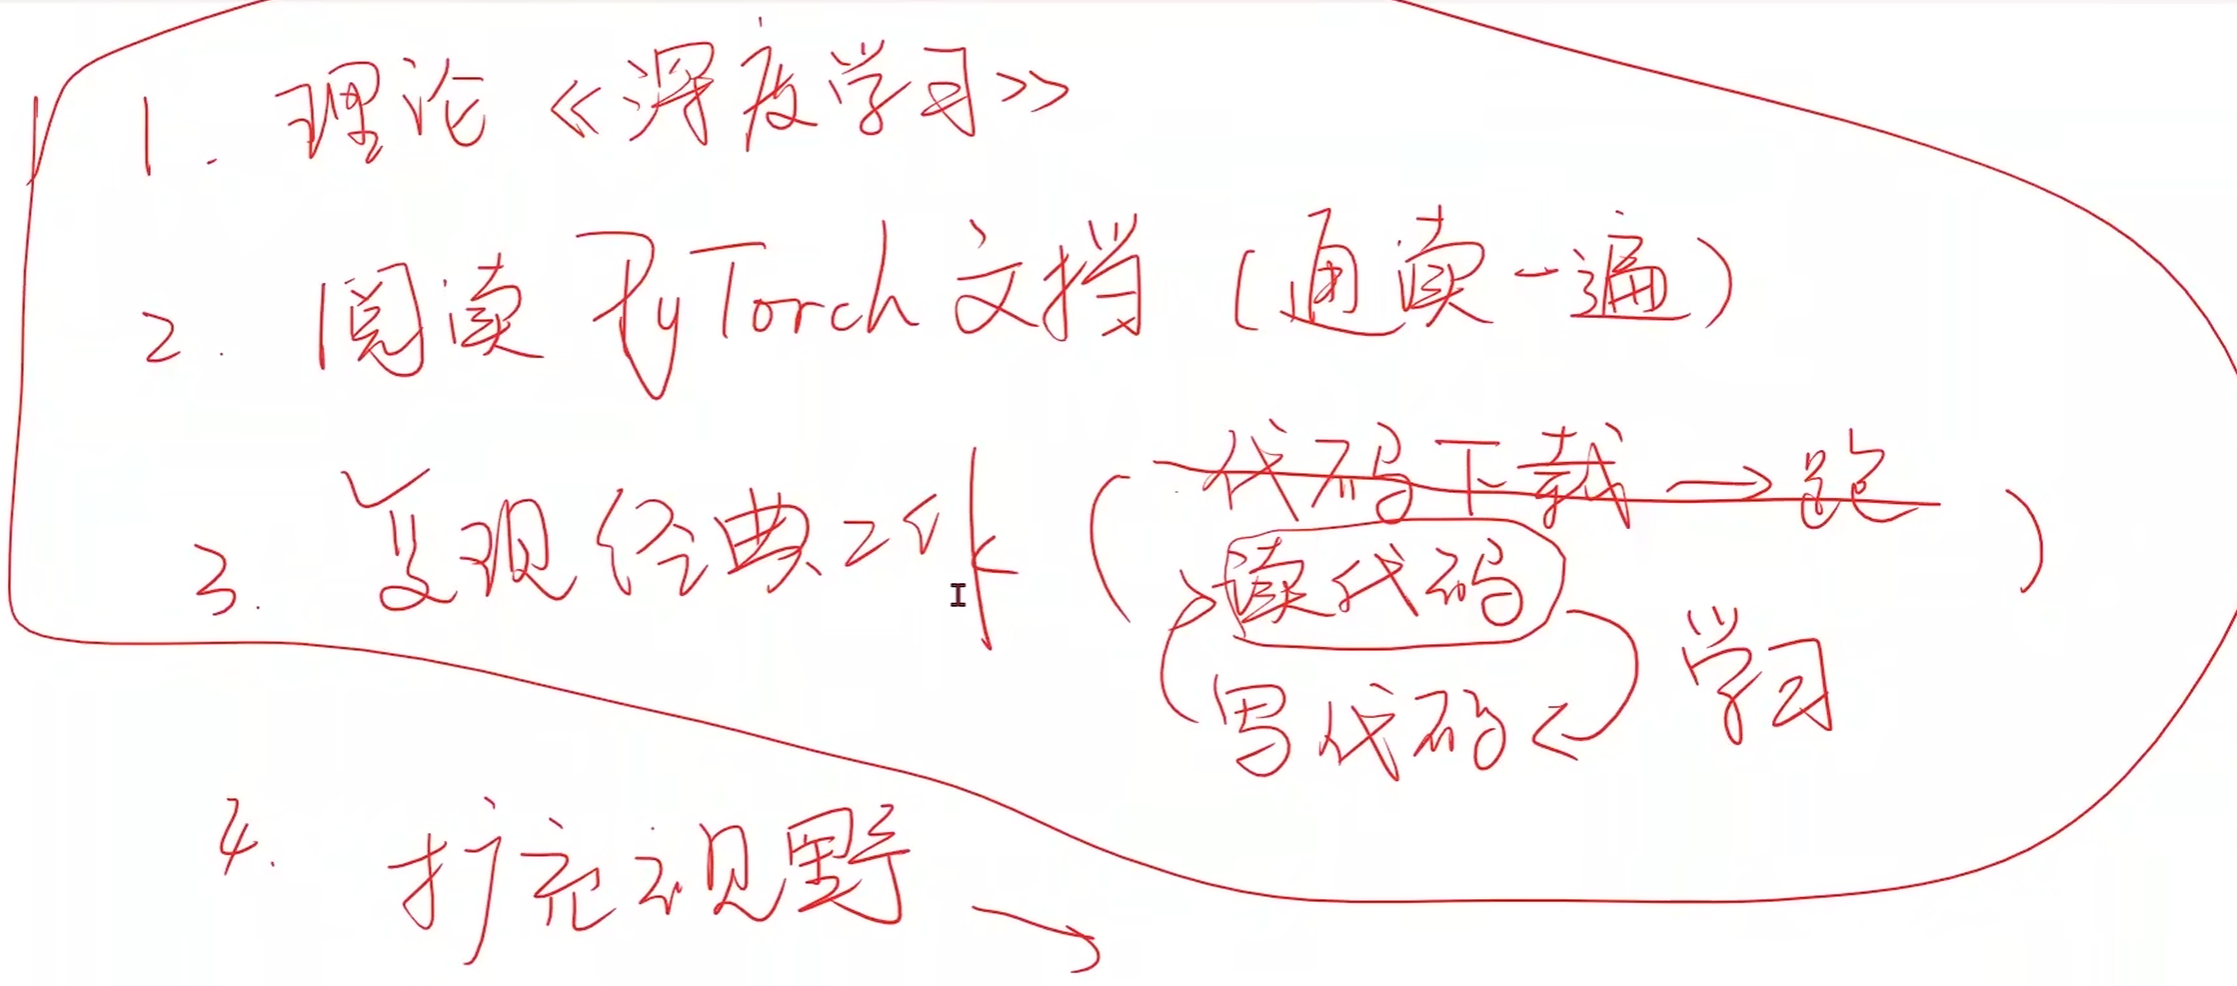